In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load AFDC Data (alt_fuel_stations_ev_charging_units (Nov 20 2024)) as a Pandas DataFrame
df = pd.read_csv('alt_fuel_stations_ev_charging_units (Nov 20 2024).csv', usecols=['Station Name', 'Street Address', 'City', 'State', 'EV Level2 EVSE Num', 'EV DC Fast Count', 'EV J1772 Connector Count', 'EV J1772 Power Output (kW)', 'EV CCS Connector Count', 'EV CCS Power Output (kW)', 'EV CHAdeMO Connector Count', 'EV CHAdeMO Power Output (kW)', 'EV J3400 Connector Count', 'EV J3400 Power Output (kW)', 'Latitude', 'Longitude'])

# Keep only San Francisco, CA rows
df = df[(df['City'] == 'San Francisco') & (df['State'] == 'CA')]

print(df.head())
print(df.info())
print(df.describe())

                            Station Name       Street Address           City  \
98            Hyatt at Fisherman's Wharf       555 N Point St  San Francisco   
103                         Palace Hotel  2 New Montgomery St  San Francisco   
104                         Palace Hotel  2 New Montgomery St  San Francisco   
105  Mark Hopkins InterContinental Hotel    999 California St  San Francisco   
500                  Beach & Hyde Garage         655 Beach St  San Francisco   

    State  EV Level2 EVSE Num  EV DC Fast Count   Latitude   Longitude  \
98     CA                 1.0               NaN  37.806190 -122.415200   
103    CA                 2.0               NaN  37.788810 -122.401000   
104    CA                 2.0               NaN  37.788810 -122.401000   
105    CA                 1.0               NaN  37.791791 -122.411265   
500    CA                 5.0               NaN  37.806798 -122.419488   

     EV J1772 Connector Count  EV J1772 Power Output (kW)  \
98           

In [3]:
# Return list of unique stations names and street address tuples where their connector count is nonzero but their power output is NaN
df_j1772 = df[df['EV J1772 Connector Count'] > 0]
df_j1772.loc[(df_j1772['EV J1772 Power Output (kW)'].isna()), ['Station Name', 'Street Address']].drop_duplicates()

,Station Name,Street Address
98,Hyatt at Fisherman's Wharf,555 N Point St
103,Palace Hotel,2 New Montgomery St
105,Mark Hopkins InterContinental Hotel,999 California St
500,Beach & Hyde Garage,655 Beach St
2120,Golden Gate Park - Music Concourse Garage,1 Music Concourse Dr
...,...,...
178509,The Summit 999,999 Green St
225471,Hotel Whitcomb - Tesla Destination,1231 Market St
226010,Hyatt Regency SOMA - Tesla Destination,50 3rd St.
226072,Holiday Inn Express & Suites San Francisco Fis...,550 North Point St.


In [4]:
df_ccs = df[df['EV CCS Connector Count'] > 0]
df_ccs.loc[(df_ccs['EV CCS Power Output (kW)'].isna()), ['Station Name', 'Street Address']].drop_duplicates()

,Station Name,Street Address
82453,SEC San Francisco,1 Yerba Buena Island


In [5]:
df_chademo = df[df['EV CHAdeMO Connector Count'] > 0]
df_chademo.loc[(df_chademo['EV CHAdeMO Power Output (kW)'].isna()), ['Station Name', 'Street Address']].drop_duplicates()

,Station Name,Street Address


In [6]:
df_j3400 = df[df['EV J3400 Connector Count'] > 0]
df_j3400.loc[(df_j3400['EV J3400 Power Output (kW)'].isna()), ['Station Name', 'Street Address']].drop_duplicates()

,Station Name,Street Address
21701,101 Second Street Garage - Tesla Destination,101 Second St.
21703,101 California Street Garage - Tesla Destination,101 California St
21705,345 California Center Parking Garage - Tesla D...,115 Battery St
21706,"Hotel Kabuki, a Joie de Vivre Hotel - Tesla De...",1625 Post St
21708,"Hotel Buchanan, a Kimpton Hotel - Tesla Destin...",1800 Sutter St
21710,Loews Regency San Francisco - Tesla Destination,222 Sansome St
21711,Hilton San Francisco Union Square - Tesla Dest...,333 O'Farrell St
21712,The Westin St. Francis San Francisco on Union ...,335 Powell St
21714,Park Central Hotel - Tesla Destination,50 3rd St
21715,The Ritz-Carlton Hotel San Francisco - Tesla D...,600 Stockton St


In [7]:
'''
For the following J1772 stations, the power output is not available in the dataset. We will manually input the power output for these stations.
Hyatt at Fisherman's Wharf
Palace Hotel
Mark Hopkins InterContinental Hotel
Beach & Hyde Garage
Golden Gate Park - Music Concourse Garage
InterContinental Hotel - San Francisco
San Francisco State University
Fort Mason
Fort Mason
JPMorgan Parking Garage
Extra Space Storage
Golden Gate National Recreation Area - Fort Mason
Fort Mason
Caltrans - District 32
Fuse Project
Department of Veterans Affairs VISN 21
"Hotel Kabuki, a Joie de Vivre Hotel - Tesla Destination"
The Ritz-Carlton Hotel San Francisco - Tesla Destination
San Francisco Marriott Marquis - Tesla Destination
The Fairmont San Francisco - Tesla Destination
San Francisco Zoo - Tesla Destination
Bay Area Metro Center
Fairmont Heritage Place Ghirardelli Square - Tesla Destination
St. Ignatius College Preparatory
Golden Gate National Recreation Area - Fort Mason
UCSF - 1630 3rd Garage
China Basin - Tesla Destination
Flickr HQ - Tesla Destination
Recology San Francisco - Tesla Destination
Adobe - SF Office - Phase 1
City of San Francisco - 49 SVN
City of San Francisco - Civic Center
FAA - National Airspace Facility (SFO ATCT)
SEC San Francisco
San Francisco International Airport - G1
San Francisco International Airport - G2
San Francisco International Airport - G5
San Francisco International Airport - G6
San Francisco International Airport - G10
San Francisco International Airport - G13
San Francisco International Airport - G7
San Francisco International Airport - G3 West
San Francisco International Airport - G3 East
San Francisco International Airport - D2 East
San Francisco International Airport - D2 West
San Francisco International Airport - D4 West
St Regis Hotel
Four Seasons Hotel
Millennium Towers
"San Francisco, CA - Letterman Drive (Wall Connector) - Tesla Destination"
JLL/Ace Parking
InterContinental Hotel San Francisco
SFO 674 North McDonnell Road Stations
SFO Courtyard 4
SFO Courtyard A
SFO Courtyard G
SFO Business Center
Bldg 710
The Summit 999
Hotel Whitcomb - Tesla Destination
Hyatt Regency SOMA - Tesla Destination
Holiday Inn Express & Suites San Francisco Fishermans Wharf - Tesla Destination
Galleria Park Hotel - Tesla Destination
'''
df.loc[(df['Station Name'] == "Hyatt at Fisherman's Wharf") & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == 'Palace Hotel') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.2
df.loc[(df['Station Name'] == 'Mark Hopkins InterContinental Hotel') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 3.4
df.loc[(df['Station Name'] == 'Beach & Hyde Garage') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.5
df.loc[(df['Station Name'] == 'Golden Gate Park - Music Concourse Garage') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == 'InterContinental Hotel - San Francisco') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 3.7
df.loc[(df['Station Name'] == 'San Francisco State University') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.5
df.loc[(df['Station Name'] == 'Fort Mason') & (df['Street Address'] == '101 Fort Mason Dr') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Fort Mason') & (df['Street Address'] == '201 Fort Mason Dr') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Fort Mason') & (df['Street Address'] == 'Building 32') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 1.8
df.loc[(df['Station Name'] == 'JPMorgan Parking Garage') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.5
df.loc[(df['Station Name'] == 'Extra Space Storage') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == 'Golden Gate National Recreation Area - Fort Mason') & (df['Street Address'] == '1300-1398 Bay St') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 7.7
df.loc[(df['Station Name'] == 'Caltrans - District 32') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Fuse Project') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 7.2
df.loc[(df['Station Name'] == 'Department of Veterans Affairs VISN 21') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 7.2
df.loc[(df['Station Name'] == 'Hotel Kabuki, a Joie de Vivre Hotel - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'The Ritz-Carlton Hotel San Francisco - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco Marriott Marquis - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == 'The Fairmont San Francisco - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.4
df.loc[(df['Station Name'] == 'San Francisco Zoo - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == 'Bay Area Metro Center') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Fairmont Heritage Place Ghirardelli Square - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'St. Ignatius College Preparatory') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 3.7
df.loc[(df['Station Name'] == 'Golden Gate National Recreation Area - Fort Mason') & (df['Street Address'] == '2 Marina Blvd') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'UCSF - 1630 3rd Garage') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 9.6
df.loc[(df['Station Name'] == 'China Basin - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Flickr HQ - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Recology San Francisco - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Adobe - SF Office - Phase 1') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'City of San Francisco - 49 SVN') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'City of San Francisco - Civic Center') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'FAA - National Airspace Facility (SFO ATCT)') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'SEC San Francisco') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G1') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G2') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G5') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G6') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G10') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G13') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G7') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G3 West') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - G3 East') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - D2 East') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - D2 West') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco International Airport - D4 West') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'St Regis Hotel') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.2
df.loc[(df['Station Name'] == 'Four Seasons Hotel') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Millennium Towers') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == "San Francisco, CA - Letterman Drive (Wall Connector) - Tesla Destination") & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'JLL/Ace Parking') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 7.2
df.loc[(df['Station Name'] == 'InterContinental Hotel San Francisco') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 3.7
df.loc[(df['Station Name'] == 'SFO 674 North McDonnell Road Stations') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'SFO Courtyard 4') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'SFO Courtyard A') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'SFO Courtyard G') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'SFO Business Center') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = 6.4
df.loc[(df['Station Name'] == 'Bldg 710') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'The Summit 999') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Hotel Whitcomb - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Hyatt Regency SOMA - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Holiday Inn Express & Suites San Francisco Fishermans Wharf - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Galleria Park Hotel - Tesla Destination') & (df['EV J1772 Connector Count'] > 0), 'EV J1772 Power Output (kW)'] = np.nan

In [8]:
'''
For the following CCS stations, the power output is not available in the dataset. We will manually input the power output for these stations.
SEC San Francisco
'''
df.loc[(df['Station Name'] == 'SEC San Francisco') & (df['EV CCS Connector Count'] > 0), 'EV CCS Power Output (kW)'] = np.nan

In [9]:
'''
For the following CHAdeMO stations, the power output is not available in the dataset. We will manually input the power output for these stations.
<No stations>
'''

'\nFor the following CHAdeMO stations, the power output is not available in the dataset. We will manually input the power output for these stations.\n<No stations>\n'

In [10]:
'''
For the following J3400 stations, the power output is not available in the dataset. We will manually input the power output for these stations.
101 Second Street Garage - Tesla Destination
101 California Street Garage - Tesla Destination
345 California Center Parking Garage - Tesla Destination
"Hotel Kabuki, a Joie de Vivre Hotel - Tesla Destination"
"Hotel Buchanan, a Kimpton Hotel - Tesla Destination"
Loews Regency San Francisco - Tesla Destination
Hilton San Francisco Union Square - Tesla Destination
The Westin St. Francis San Francisco on Union Square - Tesla Destination
Park Central Hotel - Tesla Destination
The Ritz-Carlton Hotel San Francisco - Tesla Destination
San Francisco Marriott Marquis - Tesla Destination
The Fairmont San Francisco - Tesla Destination
InterContinental Mark Hopkins San Francisco - Tesla Destination
San Francisco Zoo - Tesla Destination
Fairmont Heritage Place Ghirardelli Square - Tesla Destination
Letterman Digital Arts Center - Tesla Supercharger
Hilton San Francisco Financial District - Tesla Destination
The Masonic - Tesla Destination
Opera Plaza - Tesla Supercharger
275 Battery St - Tesla Destination
55 Second Street Garage - Tesla Destination
China Basin - Tesla Destination
Flickr HQ - Tesla Destination
Recology San Francisco - Tesla Destination
ThirdLove HQ - Tesla Destination
"San Francisco, CA - 2675 Geary Boulevard - Tesla Destination"
Hotel Whitcomb - Tesla Destination
Hyatt Regency SOMA - Tesla Destination
Holiday Inn Express & Suites San Francisco Fishermans Wharf - Tesla Destination
Luma Hotel - Tesla Destination
Galleria Park Hotel - Tesla Destination
'''
df.loc[(df['Station Name'] == '101 Second Street Garage - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == '101 California Street Garage - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 16
df.loc[(df['Station Name'] == '345 California Center Parking Garage - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 16
df.loc[(df['Station Name'] == 'Hotel Kabuki, a Joie de Vivre Hotel - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == 'Hotel Buchanan, a Kimpton Hotel - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 13
df.loc[(df['Station Name'] == 'Loews Regency San Francisco - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 16
df.loc[(df['Station Name'] == 'Hilton San Francisco Union Square - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == 'The Westin St. Francis San Francisco on Union Square - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == 'Park Central Hotel - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 16
df.loc[(df['Station Name'] == 'The Ritz-Carlton Hotel San Francisco - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == 'San Francisco Marriott Marquis - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 13
df.loc[(df['Station Name'] == 'The Fairmont San Francisco - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 13
df.loc[(df['Station Name'] == 'InterContinental Mark Hopkins San Francisco - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 13
df.loc[(df['Station Name'] == 'San Francisco Zoo - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == 'Fairmont Heritage Place Ghirardelli Square - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 13
df.loc[(df['Station Name'] == 'Letterman Digital Arts Center - Tesla Supercharger') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 72
df.loc[(df['Station Name'] == 'Hilton San Francisco Financial District - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 14
df.loc[(df['Station Name'] == 'The Masonic - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 14
df.loc[(df['Station Name'] == 'Opera Plaza - Tesla Supercharger') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 72
df.loc[(df['Station Name'] == '275 Battery St - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == '55 Second Street Garage - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 8
df.loc[(df['Station Name'] == 'China Basin - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Flickr HQ - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Recology San Francisco - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'ThirdLove HQ - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'San Francisco, CA - 2675 Geary Boulevard - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 6
df.loc[(df['Station Name'] == 'Hotel Whitcomb - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Hyatt Regency SOMA - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 10
df.loc[(df['Station Name'] == 'Holiday Inn Express & Suites San Francisco Fishermans Wharf - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Luma Hotel - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = np.nan
df.loc[(df['Station Name'] == 'Galleria Park Hotel - Tesla Destination') & (df['EV J3400 Connector Count'] > 0), 'EV J3400 Power Output (kW)'] = 10

In [11]:
# Check if each unique station name's mean value EV Level2 EVSE Num is consistent with its sum of EV J1772 Connector Count and EV J3400 Connector Count below 20 kW
# Filter away rows where EV J3400 Power Output (kW) is above 20 kW
print(len(df))
df_level2 = df[~(df['EV J3400 Power Output (kW)'] > 20)]
print(len(df_level2))
df_gb_level2 = df_level2.groupby('Station Name')[['EV Level2 EVSE Num', 'EV J1772 Connector Count', 'EV J3400 Connector Count']].agg(['median', 'sum']).fillna(0)
df_gb_level2['Count by Level'] = df_gb_level2[('EV Level2 EVSE Num', 'median')]
df_gb_level2['Count by Connector'] = df_gb_level2[('EV J1772 Connector Count', 'sum')] + df_gb_level2[('EV J3400 Connector Count', 'sum')]

# Print rows where the two counts are inconsistent
x = df_gb_level2.loc[df_gb_level2['Count by Level'] != df_gb_level2['Count by Connector'], ['Count by Connector']]
y = df_gb_level2.loc[df_gb_level2['Count by Level'] != df_gb_level2['Count by Connector'], ['Count by Level']]
print(x.values-y.values)

print(len(x))

1248
1182
[[ 2.]
 [ 4.]
 [ 2.]
 [16.]]
4


In [12]:
# Check if each unique station name's mean value EV DC Fast Count is consistent with its sum of EV CCS Connector Count, EV CHAdeMO Connector Count, and EV J3400 Connector Count
# Filter away rows where EV J3400 Power Output (kW) is below 20 kW
print(len(df))
df_dc = df[~(df['EV J3400 Power Output (kW)'] <= 20)]
print(len(df_dc))
df_gb_dc = df.groupby('Station Name')[['EV DC Fast Count', 'EV CCS Connector Count', 'EV CHAdeMO Connector Count', 'EV J3400 Connector Count']].agg(['median', 'sum']).fillna(0)
df_gb_dc['Count by Level'] = df_gb_dc[('EV DC Fast Count', 'median')]
df_gb_dc['Count by Connector'] = df_gb_dc[('EV CCS Connector Count', 'sum')] + df_gb_dc[('EV CHAdeMO Connector Count', 'sum')] + df_gb_dc[('EV J3400 Connector Count', 'sum')]

# Print rows where the two counts are inconsistent
x = df_gb_dc.loc[df_gb_dc['Count by Level'] != df_gb_dc['Count by Connector'], ['Count by Connector']]
y = df_gb_dc.loc[df_gb_dc['Count by Level'] != df_gb_dc['Count by Connector'], ['Count by Level']]
print(x.values-y.values)

print(len(x))

1248
1180
[[ 2.]
 [ 1.]
 [ 2.]
 [11.]
 [ 2.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 4.]
 [ 9.]
 [ 1.]
 [ 3.]
 [ 4.]
 [ 1.]
 [ 1.]
 [ 3.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 2.]
 [ 1.]
 [ 3.]
 [ 2.]
 [ 1.]
 [ 6.]
 [ 6.]
 [ 2.]
 [ 1.]
 [ 2.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 6.]
 [ 1.]
 [ 1.]
 [ 8.]
 [ 1.]
 [ 4.]
 [ 2.]
 [ 6.]
 [ 6.]
 [ 2.]
 [ 9.]
 [ 1.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [22.]
 [ 5.]]
54


In [13]:
# Get sorted values count of EV J1772 Power Output (kW) when EV J1772 Connector Count is greater than 0
df_j1772 = df[df['EV J1772 Connector Count'] > 0]
print(df_j1772['EV J1772 Power Output (kW)'].value_counts().sort_index())

EV J1772 Power Output (kW)
1.8       2
3.4       1
3.7       5
5.0       1
5.1       1
6.0       9
6.2      54
6.4       5
6.5     522
6.6       2
6.7      46
6.8       3
7.2      52
7.7       5
8.6      26
9.0       2
9.6      51
10.4      1
10.8      6
12.0      1
13.0      1
16.7      1
19.0      4
21.6      1
Name: count, dtype: int64


In [14]:
# Get sorted values count of EV CCS Power Output (kW) when EV CCS Connector Count is greater than 0
df_ccs = df[df['EV CCS Connector Count'] > 0]
print(df_ccs['EV CCS Power Output (kW)'].value_counts().sort_index())


EV CCS Power Output (kW)
50.0     42
62.0     12
62.5      1
100.0    14
150.0     3
350.0    42
Name: count, dtype: int64


In [15]:
# Get sorted values count of EV CHAdeMO Power Output (kW) when EV CHAdeMO Connector Count is greater than 0
df_chademo = df[df['EV CHAdeMO Connector Count'] > 0]
print(df_chademo['EV CHAdeMO Power Output (kW)'].value_counts().sort_index())


EV CHAdeMO Power Output (kW)
50.0     34
62.5     11
100.0    16
Name: count, dtype: int64


In [16]:
# Get sorted values count of EV J3400 Power Output (kW) when EV J3400 Connector Count is greater than 0
df_j3400 = df[df['EV J3400 Connector Count'] > 0]
print(df_j3400['EV J3400 Power Output (kW)'].value_counts().sort_index())


EV J3400 Power Output (kW)
6.0      17
8.0      17
10.0      9
13.0      9
14.0     11
16.0      5
62.0      2
72.0     30
250.0    34
Name: count, dtype: int64


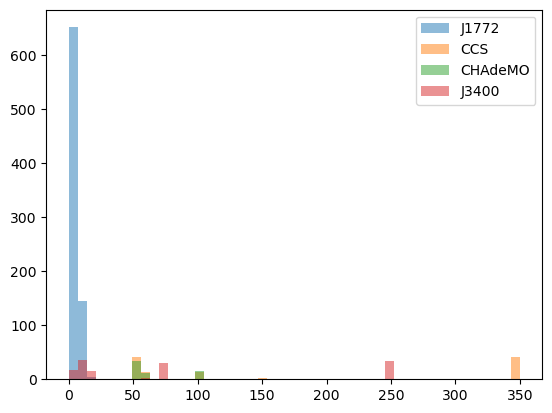

In [17]:
# Plot histogram of all power output values across all connector types
plt.figure()
plt.hist(df['EV J1772 Power Output (kW)'].dropna(), bins=np.arange(0, 357, 7), alpha=0.5, label='J1772')
plt.hist(df['EV CCS Power Output (kW)'].dropna(), bins=np.arange(0, 357, 7), alpha=0.5, label='CCS')
plt.hist(df['EV CHAdeMO Power Output (kW)'].dropna(), bins=np.arange(0, 357, 7), alpha=0.5, label='CHAdeMO')
plt.hist(df['EV J3400 Power Output (kW)'].dropna(), bins=np.arange(0, 357, 7), alpha=0.5, label='J3400')
plt.legend()
plt.show()

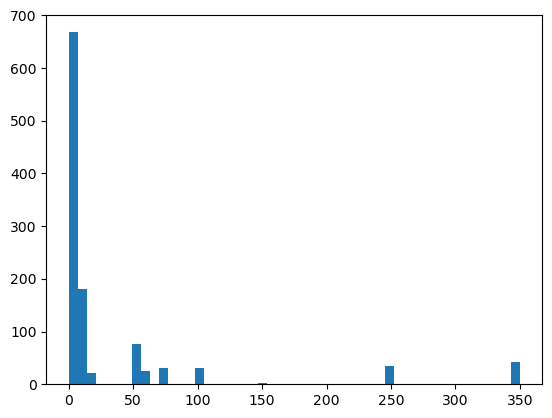

[0, 7, 49, 343, 245, 70, 98, 56, 14, 147]


In [18]:
# Create an array of all power output values across all connector types and plot its histogram with a bin width of 7 kW
power_output = np.concatenate([df['EV J1772 Power Output (kW)'].dropna().values, df['EV CCS Power Output (kW)'].dropna().values, df['EV CHAdeMO Power Output (kW)'].dropna().values, df['EV J3400 Power Output (kW)'].dropna().values])
plt.figure()
plt.hist(power_output, np.arange(0, 357, 7))
plt.show()


hist, bin_edges = np.histogram(power_output, np.arange(0, 357, 7))
# Print the bin edges corresponding to the top ten greatest frequency
print(list(reversed(bin_edges[np.argsort(hist)[-10:]])))


[[  7.15954023]
 [350.        ]
 [100.        ]
 [250.        ]
 [ 62.23076923]
 [ 50.        ]
 [150.        ]
 [ 72.        ]]


C:\Users\jthlu\anaconda3\envs\pamod\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


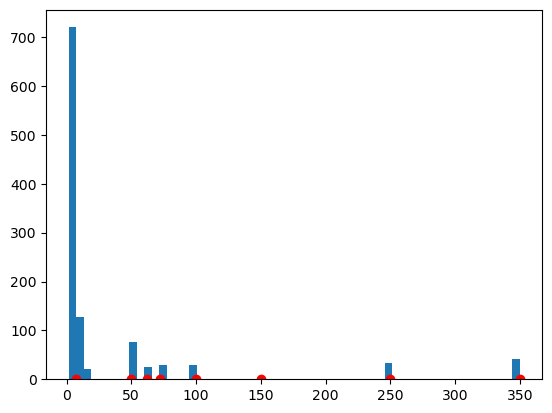

(array([0, 1, 2, 3, 4, 5, 6, 7]), array([870,  42,  30,  34,  26,  76,   3,  30], dtype=int64))


In [19]:
# Cluster the power output values into 6 clusters
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=8)
kmeans.fit(power_output.reshape(-1, 1))
print(kmeans.cluster_centers_)

# Plot the histogram of power output values and the cluster centers
plt.figure()
plt.hist(power_output, bins=60)
plt.plot(kmeans.cluster_centers_, np.zeros(8), 'ro')
plt.show()


# Print the count of each cluster
print(np.unique(kmeans.labels_, return_counts=True))


In [20]:
power_outputs = [6.6, 11.5, 50, 100, 250]

Cost per kW: [1002.95454545 1200.          721.19333333  530.91142857]
Cost per kW: [903.63636364 921.86       623.84666667 473.29714286]
Cost per kW: [ 909.09090909 1160.         1000.                   nan]
Cost per kW: [1621.21212121 1812.         1088.66666667  792.        ]
Cost per kW: [          nan 1120.          806.66666667  528.57142857]


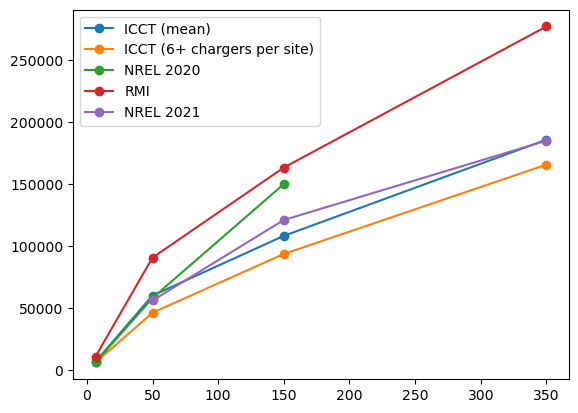

In [21]:
power = np.array([6.6, 50, 150, 350])
cost_EVSE = np.array([3127, 28401, 75000, 140000])
cost_install = np.array([(2837+4148)/2, (17692+45506)/2, (18577+47781)/2, (25654+65984)/2])
plt.plot(power, cost_EVSE + cost_install, 'o-', label='ICCT (mean)')
print("Cost per kW: {}".format((cost_EVSE + cost_install) / power))
power = np.array([6.6, 50, 150, 350])
cost_EVSE = np.array([3127, 28401, 75000, 140000])
cost_install = np.array([2837, 17692, 18577, 25654])
plt.plot(power, cost_EVSE + cost_install, 'o-', label='ICCT (6+ chargers per site)')
print("Cost per kW: {}".format((cost_EVSE + cost_install) / power))
cost_EVSE = np.array([3500, 38000, 90000, np.nan])
cost_install = np.array([2500, 20000, 60000, np.nan])
plt.plot(power, cost_EVSE + cost_install, 'o-', label='NREL 2020')
print("Cost per kW: {}".format((cost_EVSE + cost_install) / power))
cost_EVSE = np.array([(2500+4900)/2, (20000+35800)/2, (75600+100000)/2, (128000+150000)/2])
cost_install = np.array([7000, 62700, 75500, 138200])
plt.plot(power, cost_EVSE + cost_install, 'o-', label='RMI')
print("Cost per kW: {}".format((cost_EVSE + cost_install) / power))
cost_EVSE = np.array([np.nan, (20000+36000)/2, (75000+100000)/2, (128000+150000)/2])
cost_install = np.array([np.nan, (10000+46000)/2, (19000+48000)/2, (26000+66000)/2])
plt.plot(power, cost_EVSE + cost_install, 'o-', label='NREL 2021')
print("Cost per kW: {}".format((cost_EVSE + cost_install) / power))
plt.legend()
plt.show()


In [22]:
power = np.array([6.6, 50, 150, 350])
cost_EVSE = np.array([3127, 28401, 75000, 140000])
cost_install = np.array([2837, 17692, 18577, 25654])

# interpolate the data to get costs for the values in power_outputs
from scipy import interpolate
interp_cost_EVSE = interpolate.interp1d(power, cost_EVSE, fill_value='extrapolate')
interp_cost_install = interpolate.interp1d(power, cost_install, fill_value='extrapolate')
cost_EVSE_outputs = interp_cost_EVSE(power_outputs)
cost_install_outputs = interp_cost_install(power_outputs)
cost_outputs = cost_EVSE_outputs + cost_install_outputs

print("powers = ", power_outputs)
print("cost_EVSE = ", cost_EVSE_outputs)
print("cost_install = ", cost_install_outputs)
print("total costs = ", cost_outputs)
print("Cost per kW: {}".format(cost_outputs / power_outputs))




powers =  [6.6, 11.5, 50, 100, 250]
cost_EVSE =  [  3127.           5980.51612903  28401.          51700.5
 107500.        ]
cost_install =  [ 2837.          4514.17741935 17692.         18134.5
 22115.5       ]
total costs =  [  5964.          10494.69354839  46093.          69835.
 129615.5       ]
Cost per kW: [903.63636364 912.58204769 921.86       698.35       518.462     ]


# Save SF Charging Stations to data file

In [23]:
df

,Station Name,Street Address,City,State,EV Level2 EVSE Num,EV DC Fast Count,Latitude,Longitude,EV J1772 Connector Count,EV J1772 Power Output (kW),EV CCS Connector Count,EV CCS Power Output (kW),EV CHAdeMO Connector Count,EV CHAdeMO Power Output (kW),EV J3400 Connector Count,EV J3400 Power Output (kW)
98,Hyatt at Fisherman's Wharf,555 N Point St,San Francisco,CA,1.0,NaN,37.806190,-122.415200,1,6.0,0,NaN,0,NaN,0,NaN
103,Palace Hotel,2 New Montgomery St,San Francisco,CA,2.0,NaN,37.788810,-122.401000,1,6.2,0,NaN,0,NaN,0,NaN
104,Palace Hotel,2 New Montgomery St,San Francisco,CA,2.0,NaN,37.788810,-122.401000,1,6.2,0,NaN,0,NaN,0,NaN
105,Mark Hopkins InterContinental Hotel,999 California St,San Francisco,CA,1.0,NaN,37.791791,-122.411265,1,3.4,0,NaN,0,NaN,0,NaN
500,Beach & Hyde Garage,655 Beach St,San Francisco,CA,5.0,NaN,37.806798,-122.419488,2,6.5,0,NaN,0,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230015,The Linden,200 Linden Avenue,San Francisco,CA,19.0,NaN,37.654399,-122.410226,1,6.7,0,NaN,0,NaN,0,NaN
230016,The Linden,200 Linden Avenue,San Francisco,CA,19.0,NaN,37.654399,-122.410226,1,6.7,0,NaN,0,NaN,0,NaN
230017,The Linden,200 Linden Avenue,San Francisco,CA,19.0,NaN,37.654399,-122.410226,1,6.7,0,NaN,0,NaN,0,NaN
230018,The Linden,200 Linden Avenue,San Francisco,CA,19.0,NaN,37.654399,-122.410226,1,6.7,0,NaN,0,NaN,0,NaN


In [24]:
import geopandas as gpd
import os
import pickle
from pamodpy.Station import Station
from pamodpy.EVSE import EVSE

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude)).set_crs(epsg=4326)

# Load TAZ GeoDataFrame
SF_map = gpd.read_file(os.path.join("SF_190",
                     'Justin-Luke---Academic_SF-TAZ-with-added-boundary-pass-through_ZoneSet',
                     'zone_set_SF_TAZ_with_added_boundary_pass_through.shp'))
SF_map = SF_map.set_index('name')
SF_map.index = SF_map.index.astype(int)
SF_map = SF_map.sort_index()

# Merged GeoDataFrame; column "index_right" is the TAZ corresponding to the station (each row)
joined_gdf = gpd.sjoin(gdf, SF_map, predicate='within')
print(joined_gdf.size)
print(joined_gdf.columns)

22000
Index(['Station Name', 'Street Address', 'City', 'State', 'EV Level2 EVSE Num',
       'EV DC Fast Count', 'Latitude', 'Longitude', 'EV J1772 Connector Count',
       'EV J1772 Power Output (kW)', 'EV CCS Connector Count',
       'EV CCS Power Output (kW)', 'EV CHAdeMO Connector Count',
       'EV CHAdeMO Power Output (kW)', 'EV J3400 Connector Count',
       'EV J3400 Power Output (kW)', 'geometry', 'index_right', 'id',
       'direction', 'is_pass', 'is_bidi'],
      dtype='object')


In [25]:
evse_name_to_power_range = {
    'AC 6.6kW': [5, (6.6 + 11.5) / 2],
    'AC 11.5kW': [(6.6 + 11.5) / 2, (11.5 + 50) / 2],
    'DC 50kW': [(11.5 + 50) / 2, 351],
}
power_output_col_to_connector_count_col = {
    'EV J1772 Power Output (kW)': 'EV J1772 Connector Count',
    'EV CCS Power Output (kW)': 'EV CCS Connector Count',
    'EV CHAdeMO Power Output (kW)': 'EV CHAdeMO Connector Count',
    'EV J3400 Power Output (kW)': 'EV J3400 Connector Count'
}


cluster_to_taz = {
            1: [56, 57],
            2: [52, 62, 65, 66],
            3: [43, 48, 49, 50, 51, 70, 71, 72],
            4: [6, 7, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 26, 39, 40, 41, 44, 45, 46, 47, 73, 74, 75],
            5: [1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 26, 37, 38, 42],
            6: [54, 55, 58, 59, 60],
            7: [53, 61, 63, 64, 67, 90],
            8: [68, 69, 83, 84, 85, 86, 87, 88, 89],
            9: [8, 9, 10, 11, 20, 76, 77, 78, 79, 80, 81, 82, 104, 105, 106, 107],
            10: [18, 19, 21, 108, 109, 110],
            11: [178, 179, 180, 181, 184],
            12: [172, 173, 174, 175, 176, 177, 185],
            13: [91, 92, 93, 94, 95, 96, 129, 171],
            14: [97, 98, 99, 100, 101, 102, 103, 116, 117, 118, 119, 122, 123, 128],
            15: [111, 112, 113, 114, 115, 120, 121, 142],
            16: [182, 183, 186, 187],
            17: [169, 170, 188],
            18: [130, 131, 132, 133, 134],
            19: [124, 125, 126, 127, 135, 136, 137, 138, 152],
            20: [139, 140, 141, 143, 144, 145, 146, 147, 150],
            21: [190],
            22: [168, 189],
            23: [161, 162, 163, 164, 165, 166, 167],
            24: [155, 156, 157, 158, 159, 160],
            25: [148, 149, 151, 153, 154]
}

charge_stations_25 = {}
for l in range(1, 26):
    station = Station(l, l)
    charge_stations_25[l] = []

    for evse_name, power_range in evse_name_to_power_range.items():
        UMax_charge_evse = 0
        if evse_name != 'DC 50kW':
            for power_output_col, connector_count_col in power_output_col_to_connector_count_col.items():
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= power_range[0]) & (joined_gdf[power_output_col] < power_range[1]), connector_count_col].sum()
        else:
            for power_output_col, connector_count_col in power_output_col_to_connector_count_col.items():
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= power_range[0]) & (joined_gdf[power_output_col] < 75), connector_count_col].sum()
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= 75) & (joined_gdf[power_output_col] < 125), connector_count_col].sum() * 2
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= 125) & (joined_gdf[power_output_col] < 175), connector_count_col].sum() * 3
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= 175) & (joined_gdf[power_output_col] < 225), connector_count_col].sum() * 4
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= 225) & (joined_gdf[power_output_col] < 275), connector_count_col].sum() * 5
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= 275) & (joined_gdf[power_output_col] < 325), connector_count_col].sum() * 6
                UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= 325) & (joined_gdf[power_output_col] < 375), connector_count_col].sum() * 7
        if UMax_charge_evse != 0:
            station.EVSEs.append(EVSE(evse_name, UMax_charge_evse, station))
    if station.EVSEs != []:
        charge_stations_25[l].append(station)

with open('SF_25/SF_charging_stations_50kW_to_25_cluster.p', 'wb') as f:
    pickle.dump(charge_stations_25, f)



In [41]:
# evse_name_to_power_range = {
#     'AC 6.6kW': [5, (6.6 + 11.5) / 2],
#     'AC 11.5kW': [(6.6 + 11.5) / 2, (11.5 + 50) / 2],
#     'DC 50kW': [(11.5 + 50) / 2, (50 + 100) / 2],
#     'DC 100kW': [(50 + 100) / 2, (100 + 250) / 2],
#     'DC 250kW': [(100 + 250) / 2, 351]
# }
# power_output_col_to_connector_count_col = {
#     'EV J1772 Power Output (kW)': 'EV J1772 Connector Count',
#     'EV CCS Power Output (kW)': 'EV CCS Connector Count',
#     'EV CHAdeMO Power Output (kW)': 'EV CHAdeMO Connector Count',
#     'EV J3400 Power Output (kW)': 'EV J3400 Connector Count'
# }
#
# charge_stations_190 = {}
# for l in range(1, 191):
#     station = Station(l, l)
#     charge_stations_190[l] = []
#     for evse_name, power_range in evse_name_to_power_range.items():
#         UMax_charge_evse = 0
#         for power_output_col, connector_count_col in power_output_col_to_connector_count_col.items():
#             UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right == l) & (joined_gdf[power_output_col] >= power_range[0]) & (joined_gdf[power_output_col] < power_range[1]), connector_count_col].sum()
#         if UMax_charge_evse != 0:
#             station.EVSEs.append(EVSE(evse_name, UMax_charge_evse, station))
#     if station.EVSEs != []:
#         charge_stations_190[l].append(station)
#
# print(charge_stations_190)
#
# cluster_to_taz = {
#             1: [56, 57],
#             2: [52, 62, 65, 66],
#             3: [43, 48, 49, 50, 51, 70, 71, 72],
#             4: [6, 7, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 26, 39, 40, 41, 44, 45, 46, 47, 73, 74, 75],
#             5: [1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 26, 37, 38, 42],
#             6: [54, 55, 58, 59, 60],
#             7: [53, 61, 63, 64, 67, 90],
#             8: [68, 69, 83, 84, 85, 86, 87, 88, 89],
#             9: [8, 9, 10, 11, 20, 76, 77, 78, 79, 80, 81, 82, 104, 105, 106, 107],
#             10: [18, 19, 21, 108, 109, 110],
#             11: [178, 179, 180, 181, 184],
#             12: [172, 173, 174, 175, 176, 177, 185],
#             13: [91, 92, 93, 94, 95, 96, 129, 171],
#             14: [97, 98, 99, 100, 101, 102, 103, 116, 117, 118, 119, 122, 123, 128],
#             15: [111, 112, 113, 114, 115, 120, 121, 142],
#             16: [182, 183, 186, 187],
#             17: [169, 170, 188],
#             18: [130, 131, 132, 133, 134],
#             19: [124, 125, 126, 127, 135, 136, 137, 138, 152],
#             20: [139, 140, 141, 143, 144, 145, 146, 147, 150],
#             21: [190],
#             22: [168, 189],
#             23: [161, 162, 163, 164, 165, 166, 167],
#             24: [155, 156, 157, 158, 159, 160],
#             25: [148, 149, 151, 153, 154]
# }
#
# charge_stations_25 = {}
# for l in range(1, 26):
#     station = Station(l, l)
#     charge_stations_25[l] = []
#
#     for evse_name, power_range in evse_name_to_power_range.items():
#         UMax_charge_evse = 0
#         for power_output_col, connector_count_col in power_output_col_to_connector_count_col.items():
#             UMax_charge_evse += joined_gdf.loc[(joined_gdf.index_right.isin(cluster_to_taz[l])) & (joined_gdf[power_output_col] >= power_range[0]) & (joined_gdf[power_output_col] < power_range[1]), connector_count_col].sum()
#         if UMax_charge_evse != 0:
#             station.EVSEs.append(EVSE(evse_name, UMax_charge_evse, station))
#     if station.EVSEs != []:
#         charge_stations_25[l].append(station)
#
# print(charge_stations_25)
# with open('SF_190/SF_charging_stations_to_190_TAZ.p', 'wb') as f:
#     pickle.dump(charge_stations_190, f)
#
# with open('SF_25/SF_charging_stations_to_25_cluster.p', 'wb') as f:
#     pickle.dump(charge_stations_25, f)
